<a href="https://colab.research.google.com/github/AllaYermilko/DTA-2026/blob/main/homework/pandas_tasks_beginners_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практичні завдання з pandas для початківців

**Мета:** Набути базових навичок роботи з бібліотекою pandas для аналізу табличних даних.

**Інструкції:**
- Виконуйте завдання послідовно — кожне наступне спирається на попередні.
- Після виконання кожного завдання напишіть короткий висновок у комірці `**Висновок:**`.
- Не змінюйте код у комірках з підготовкою даних.

**Набір даних:** Умовна таблиця продажів інтернет-магазину за 2023 рік.

---
## Підготовка: Генерація тестових даних

Запустіть цю комірку перед початком роботи. Не змінюйте код.

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

categories = ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт']
cities = ['Київ', 'Харків', 'Одеса', 'Дніпро', 'Львів']
payment_methods = ['Картка', 'Готівка', 'Онлайн']

df = pd.DataFrame({
    'order_id':        range(1001, 1001 + n),
    'date':            pd.date_range('2023-01-01', periods=n, freq='D')[:n],
    'category':        np.random.choice(categories, n),
    'product':         ['Товар_' + str(i) for i in np.random.randint(1, 51, n)],
    'city':            np.random.choice(cities, n),
    'quantity':        np.random.randint(1, 10, n),
    'price':           np.round(np.random.uniform(50, 5000, n), 2),
    'payment_method':  np.random.choice(payment_methods, n),
    'rating':          np.random.choice([1, 2, 3, 4, 5, np.nan], n, p=[0.05, 0.1, 0.15, 0.3, 0.3, 0.1]),
    'is_returned':     np.random.choice([True, False], n, p=[0.1, 0.9]),
})

# Додаємо кілька пропущених значень
df.loc[np.random.choice(df.index, 10, replace=False), 'city'] = np.nan
df.loc[np.random.choice(df.index, 5, replace=False), 'price'] = np.nan

# Розраховуємо загальну суму
df['total'] = df['quantity'] * df['price']

print('Дані успішно згенеровано. Рядків:', len(df))
print('Колонки:', list(df.columns))

Дані успішно згенеровано. Рядків: 200
Колонки: ['order_id', 'date', 'category', 'product', 'city', 'quantity', 'price', 'payment_method', 'rating', 'is_returned', 'total']


---
## Завдання 1 (Легке). Перший погляд на дані

Виведіть перші 10 рядків датафрейму `df` та отримайте загальну інформацію про нього (кількість рядків, колонок, типи даних) за допомогою методів `head()` та `info()`.

In [3]:
# Ваш код тут
df.head(10)

,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total
0,1001,2023-01-01,Продукти,Товар_34,Київ,1,963.38,Картка,5.0,False,963.38
1,1002,2023-01-02,Спорт,Товар_6,Львів,6,1086.28,Картка,4.0,False,6517.68
2,1003,2023-01-03,Книги,Товар_22,Дніпро,4,1883.84,Готівка,5.0,False,7535.36
3,1004,2023-01-04,Спорт,Товар_11,Дніпро,1,2448.39,Картка,5.0,False,2448.39
4,1005,2023-01-05,Спорт,Товар_48,Дніпро,7,3110.36,Онлайн,3.0,False,21772.52
5,1006,2023-01-06,Одяг,Товар_16,Львів,9,1876.12,Онлайн,NaN,False,16885.08
6,1007,2023-01-07,Книги,Товар_33,Дніпро,4,2339.55,Картка,4.0,False,9358.20
7,1008,2023-01-08,Книги,Товар_9,Львів,4,3749.98,Готівка,4.0,False,14999.92
8,1009,2023-01-09,Книги,Товар_6,Дніпро,6,231.58,Онлайн,4.0,False,1389.48
9,1010,2023-01-10,Спорт,Товар_16,Одеса,3,1299.56,Готівка,1.0,False,3898.68


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        200 non-null    int64         
 1   date            200 non-null    datetime64[ns]
 2   category        200 non-null    object        
 3   product         200 non-null    object        
 4   city            190 non-null    object        
 5   quantity        200 non-null    int64         
 6   price           195 non-null    float64       
 7   payment_method  200 non-null    object        
 8   rating          177 non-null    float64       
 9   is_returned     200 non-null    bool          
 10  total           195 non-null    float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 15.9+ KB


**Висновок:**
Датафрейм містить 200 рядків, 11 колонок.  
У таблиці зустрічаються 5 типів даних: int64, float64, datetime64[ns], bool та object.  
У датафреймі є пропущені значення у чотирьох колонках: city, price, rating та total.

---
## Завдання 2 (Легке). Описова статистика

Використайте метод `describe()` для отримання описової статистики числових колонок. Окремо виведіть мінімум, максимум і середнє значення колонки `price`.

In [5]:
# Ваш код тут
df.describe()

,order_id,date,quantity,price,rating,total
count,200.000000,200,200.000000,195.000000,177.000000,195.000000
mean,1100.500000,2023-04-10 12:00:00,4.700000,2500.579641,3.813559,11629.097590
min,1001.000000,2023-01-01 00:00:00,1.000000,139.650000,1.000000,149.350000
25%,1050.750000,2023-02-19 18:00:00,2.000000,1288.215000,3.000000,3893.955000
50%,1100.500000,2023-04-10 12:00:00,5.000000,2517.290000,4.000000,8746.840000
75%,1150.250000,2023-05-30 06:00:00,7.000000,3706.975000,5.000000,16922.420000
max,1200.000000,2023-07-19 00:00:00,9.000000,4950.300000,5.000000,44324.640000
std,57.879185,NaN,2.618066,1380.066748,1.169808,9968.293697


**Висновок:**  
Мінімальна ціна товару - 139,65 грн, максимальна - 4950,30 грн.
Середня ціна (mean) - 2500,58 грн, медіана- 2517,29 грн, що свідчить про збалансований розподіл цін.  
У даних є суттєвий розкид: в асортименті є як дуже дешеві, так і дорогі товари.

---
## Завдання 3 (Легке). Пропущені значення

Знайдіть кількість пропущених значень у кожній колонці за допомогою `isnull().sum()`. Визначте, який відсоток рядків має пропущені значення хоча б в одній колонці (`dropna()` та `len()`).

In [6]:
# Ваш код тут
df.isnull().sum()



,0
order_id,0
date,0
category,0
product,0
city,10
quantity,0
price,5
payment_method,0
rating,23
is_returned,0


**Висновок:**   
city — 10 пропусків  
price — 5 пропусків  
rating — 23 пропуски  
total — 5 пропусків  
Пропуски у колонках price та total є критичними, тому що це головні фінансові показники. Без них неможливо точно розрахувати загальний прибуток, середній чек  та визначити найприбутковіші товари.  
Пропуски у колонці city мають середню критичність, вони заважатимуть лише в тому випадку, якщонеобхідно буде зробити аналіз продажів у розрізі регіонів чи логістики. На загальний фінансовий підсумок компанії відсутність назви міста ніяк не впливає.    
Пропуски у колонці rating не критичні

---
## Завдання 4 (Легке). Відбір колонок і рядків

Створіть новий датафрейм `df_subset`, що містить лише колонки `order_id`, `category`, `city`, `total`. Потім виведіть рядки з індексами від 10 до 20 включно за допомогою `.iloc[]`.

In [7]:
# Ваш код тут
df_subset = df[['order_id', 'category', 'city', 'total']]
df_subset.iloc[10:21, 1:]

,category,city,total
10,Продукти,Дніпро,21486.48
11,Книги,Львів,31368.89
12,Спорт,Харків,7748.40
13,Одяг,Дніпро,18787.72
14,Продукти,NaN,1741.50
15,Одяг,Одеса,4529.38
16,Продукти,Київ,10745.84
17,Спорт,Одеса,10001.84
18,Електроніка,Дніпро,12444.75
19,Продукти,Харків,13422.92


**Висновок:**  
Через список назв ми вибираємо дані за їхніми іменами.  
Через iloc дані вибираються виключно за їхніми координатами.

---
## Завдання 5 (Легке). Фільтрація даних

Відфільтруйте датафрейм і отримайте:
1. Всі замовлення з категорії `'Електроніка'`.
2. Всі замовлення, де `price` перевищує 2000.
3. Поверненi замовлення (`is_returned == True`) з міста `'Київ'`.

Виведіть кількість рядків для кожного фільтру.

In [8]:
# Ваш код тут
from enum import unique
# Ваш код тут
print(len(df[df['category'] =='Електроніка'])/df.shape[0]*100)
# df[df['price'] > 2000]
print(df[(df['is_returned'] ==True) & (df['city'] == 'Київ')].shape[0]/df[df['is_returned'] ==True].shape[0]*100)
print(df[(df['is_returned'] ==True) & (df['city'] == 'Київ')].shape[0]/df[df['city'] =='Київ'].shape[0]*100)
print(df['city'].unique())
returned_by_city = df.groupby('city').agg(count = ('order_id', 'count'), is_ret = ('is_returned', 'sum'))
returned_by_city['percent'] = (returned_by_city['is_ret']/returned_by_city['count']*100).round(2)
display(returned_by_city.sort_values(by='percent'))
display(returned_by_city)

21.5
28.000000000000004
18.91891891891892
['Київ' 'Львів' 'Дніпро' 'Одеса' 'Харків' nan]


,count,is_ret,percent
city,,,
Дніпро,38,2,5.26
Харків,39,3,7.69
Львів,46,5,10.87
Київ,37,7,18.92
Одеса,30,7,23.33


,count,is_ret,percent
city,,,
Дніпро,38,2,5.26
Київ,37,7,18.92
Львів,46,5,10.87
Одеса,30,7,23.33
Харків,39,3,7.69


**Висновок:**
Трохи більше ніж кожне п'яте замовлення в магазині припадає на категорію «Електроніка» (21,5% від усіх транзакцій).  
Повернення з Києва серед усіх повернень становить 28%, це більше ніж чверть від усіх замовлень. Частка повернень всередині Києва складає 18,92%. Майже кожне п'яте замовлення з Києва завершується поверненням товару.

---
## Завдання 6 (Середнє). Сортування та ранжування

1. Відсортуйте датафрейм за колонкою `total` у спадному порядку та виведіть топ-10 найбільших замовлень.
2. Додайте нову колонку `rank`, що містить порядковий номер замовлення за розміром суми (від найбільшого до найменшого) за допомогою `.rank()`.

In [9]:
# Ваш код тут
df['rank'] = df['total'].rank(ascending=False, method = 'min')
df.sort_values('total', ascending=False).head(10)

,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
190,1191,2023-07-10,Одяг,Товар_22,Київ,9,4924.96,Готівка,4.0,True,44324.64,1.0
58,1059,2023-02-28,Продукти,Товар_33,Харків,9,4848.88,Картка,5.0,False,43639.92,2.0
186,1187,2023-07-06,Спорт,Товар_34,Київ,9,4675.12,Готівка,5.0,False,42076.08,3.0
55,1056,2023-02-25,Електроніка,Товар_3,Дніпро,8,4912.77,Картка,5.0,False,39302.16,4.0
169,1170,2023-06-19,Продукти,Товар_50,Київ,8,4739.05,Готівка,5.0,False,37912.40,5.0
191,1192,2023-07-11,Спорт,Товар_25,Харків,9,4202.55,Готівка,4.0,True,37822.95,6.0
193,1194,2023-07-13,Одяг,Товар_22,NaN,8,4608.17,Картка,4.0,False,36865.36,7.0
51,1052,2023-02-21,Продукти,Товар_35,Дніпро,8,4488.99,Онлайн,4.0,False,35911.92,8.0
25,1026,2023-01-26,Книги,Товар_18,Дніпро,8,4458.11,Картка,3.0,False,35664.88,9.0
143,1144,2023-05-24,Продукти,Товар_31,Київ,9,3732.53,Готівка,5.0,False,33592.77,10.0


**Висновок:**   
Найбільше замовлення на суму 44324,64 грн належить категорії «Одяг».  
На другому місці йде категорія «Продукти» із сумою 43639,92 грн.  

---
## Завдання 7 (Середнє). Групування та агрегація

За допомогою `groupby()` розрахуйте для кожної категорії товарів:
- загальний обсяг продажів (сума `total`),
- кількість замовлень,
- середню ціну (`price`).

Відсортуйте результат за загальним обсягом продажів.

,total_sum,total_count,price_mean
category,,,
Продукти,583761.68,47,2513.979787
Одяг,474135.61,34,2707.906176
Електроніка,428129.79,43,2334.470698
Спорт,400802.56,35,2494.205143
Книги,380844.39,36,2491.881944


<Axes: xlabel='category'>

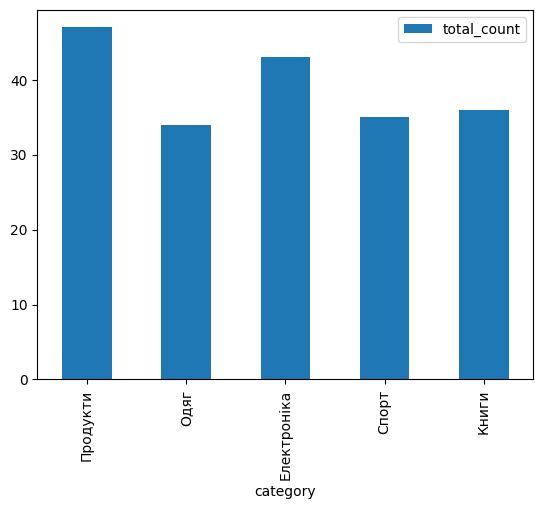

In [10]:
# Ваш код тут
category_stats = df.groupby('category').agg(
    total_sum=('total', 'sum'),
    total_count=('total', 'count'),
    price_mean=('price', 'mean')
).sort_values('total_sum', ascending=False)

display(category_stats)

category_stats.plot(kind='bar', y='total_count')

**Висновок:**  
Найбільший дохід приносить категорія «Продукти» із сумарною виручкою 583761,68 грн, на цю категорію припадає найбільша кількість замовлень.

---
## Завдання 8 (Середнє). Обробка пропущених значень

1. Заповніть пропущені значення в колонці `price` медіаною цін відповідної категорії (використайте `groupby().transform('median')`).
2. Заповніть пропущені значення в колонці `city` рядком `'Невідомо'`.
3. Пропущені значення в `rating` залиште без змін — поясніть чому у висновку.

Перевірте, що пропусків у `price` та `city` більше немає.

In [11]:
# Ваш код тут
df['price'] = df['price'].fillna(df.groupby('category')['price'].transform('median'))

df['city'] = df['city'].fillna('Невідомо')

print(df[['price', 'city', 'rating']].isnull().sum())

price      0
city       0
rating    23
dtype: int64


**Висновок:**  
Медіана стійка до викидів. Якщо в категорії є один надто дорогий товар, він сильно завищить середнє значення, але майже не змінить медіану, тому заповнення медіаною буде набагато точнішим.  
Багато клієнтів не залишають відгуків, а штучне заповнення цих пропусків може викривляти реальну статистику.

---
## Завдання 9 (Середнє). Додавання обчислюваних колонок

Додайте до датафрейму нові колонки:
1. `month` — місяць замовлення (з колонки `date`).
2. `price_category` — категорія ціни: `'Низька'` (до 500), `'Середня'` (500–2000), `'Висока'` (понад 2000). Використайте `pd.cut()` або `np.select()`.
3. `discount_total` — сума зі знижкою 15%.

/tmp/ipykernel_2271/1494567907.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = (df.groupby('price_category').agg(total_sum = ('total', 'sum'), count = ('order_id', 'count')).plot(kind='pie', y = 'total_sum'))
/tmp/ipykernel_2271/1494567907.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('price_category').agg(total_sum = ('total', 'sum'), count = ('order_id', 'count')))


,total_sum,count
price_category,,
Низька,11758.34,9
Середня,440137.78,70
Висока,1815777.91,121


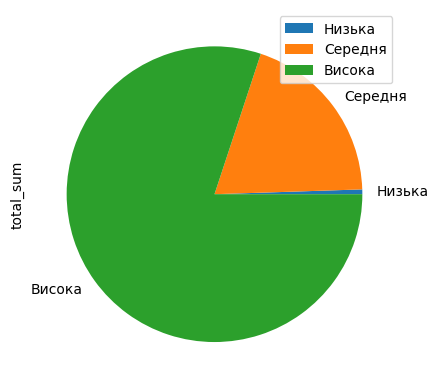

In [12]:
# Ваш код тут
import numpy as np
df['month'] = df['date'].dt.month
df['price_category'] = pd.cut(df['price'], bins = [0, 500, 2000, float('inf')], labels = ['Низька', 'Середня', 'Висока'])
df['price_category2'] = np.select([df['price']<500, df['price']>2000], ['Низька', 'Висока'], default = 'Середня')
df['discount_total '] = (df['total']*0.85).round(2)
df['discount_total'] = 'df'
x = (df.groupby('price_category').agg(total_sum = ('total', 'sum'), count = ('order_id', 'count')).plot(kind='pie', y = 'total_sum'))
display(df.groupby('price_category').agg(total_sum = ('total', 'sum'), count = ('order_id', 'count')))

**Висновок:**  
Найбільшу частку замовлень має «Висока» цінова категорія — 121 замовлення. Вона ж приносить найбільше доходу (понад 1,88 млн).  
Категорія «Середня» займає друге місце з 70 замовленнями (близько 440 тис. доходу).  
Категорія «Низька» включає лише 9 замовлень та дає мінімальний внесок у загальну суму.
Метод pd.cut виконує автоматичний поділ чисел на задані інтервали та автоматично присвоює текстові мітки.

---
## Завдання 10 (Середнє). Зведена таблиця (pivot table)

Побудуйте зведену таблицю за допомогою `pd.pivot_table()`, де:
- рядки — `city`,
- колонки — `category`,
- значення — сума `total`,
- агрегація — `sum`.

Додайте підсумки по рядках і колонках (`margins=True`).

In [13]:
# Ваш код тут
pivot_revenue = pd.pivot_table(
    df,
    index='city',
    columns='category',
    values='total',
    aggfunc='sum',
    margins=True,
    margins_name='Всього'
)

display(pivot_revenue)

category,Електроніка,Книги,Одяг,Продукти,Спорт,Всього
city,,,,,,
Дніпро,65438.16,116118.97,31179.87,147336.56,72244.38,432317.94
Київ,58713.88,87339.03,103754.43,118283.10,113742.95,481833.39
Львів,154285.60,108959.19,74340.69,55768.80,43155.08,436509.36
Невідомо,21012.44,25984.45,46962.31,40508.03,5917.59,140384.82
Одеса,84611.65,26773.57,82361.08,60466.75,65539.34,319752.39
Харків,44068.06,15669.18,135537.23,161398.44,100203.22,456876.13
Всього,428129.79,380844.39,474135.61,583761.68,400802.56,2267674.03


**Висновок:**  
Найвищий сумарний дохід приносить місто Харків та категорія «Продукти» — вони разом згенерували 161398.44 грн.  
Margins відображають загальні підсумки продажів. Нижній рядок "Всього" показує сумарний дохід кожної категорії по всіх містах (лідером є категорія "Продукти" з сумою 583761,68 грн.) Колонка праворуч відображає сумарний дохід кожного міста по всіх категоріях (лідер — Київ з сумою  481833,39 грн.), а нижня права комірка вказує на фінальний виторг усього магазину (2267674,03 грн).


---
## Завдання 11 (Середнє). Підрахунок унікальних значень і частот

1. Підрахуйте кількість унікальних товарів (`product`) у кожній категорії.
2. Виведіть топ-5 найпопулярніших товарів за кількістю замовлень за допомогою `value_counts()`.
3. Визначте частку кожного способу оплати у відсотках (`normalize=True`).

In [14]:
# Ваш код тут
# Підрахуйте кількість унікальних товарів (product) у кожній категорії.
print("Унікальних товарів у категоріях:")
print(df.groupby('category')['product'].nunique())
print("-" * 40)

# Виведіть топ-5 найпопулярніших товарів за кількістю замовлень за допомогою value_counts().
print("Топ-5 найпопулярніших товарів:")
print(df['product'].value_counts().head(5))
print("-" * 40)

# Визначте частку кожного способу оплати у відсотках (normalize=True).
print("Частка способів оплати (%):")
print((df['payment_method'].value_counts(normalize=True) * 100).round(2))

Унікальних товарів у категоріях:
category
Електроніка    32
Книги          25
Одяг           27
Продукти       30
Спорт          25
Name: product, dtype: int64
----------------------------------------
Топ-5 найпопулярніших товарів:
product
Товар_33    11
Товар_48     9
Товар_35     9
Товар_22     7
Товар_20     6
Name: count, dtype: int64
----------------------------------------
Частка способів оплати (%):
payment_method
Готівка    34.0
Онлайн     33.5
Картка     32.5
Name: proportion, dtype: float64


**Висновок:**  
Найпопулярніший спосіб оплати - готівка, становить 34% .  
Частка сплати онлайн та оплати карткою  становлять 33,5% та 32,5% відповідно, що свідчить про рівномірний розмоділ між способами оплати.

---
## Завдання 12 (Середнє). Аналіз повернень

Розрахуйте рівень повернень (частку повернених замовлень) для кожної категорії та кожного міста. Визначте:
- категорію з найвищим рівнем повернень,
- місто з найнижчим рівнем повернень.

Підказка: використайте `groupby()['is_returned'].mean()`.

In [24]:
# Ваш код тут

# Розрахуйте категорію з найвищим рівнем повернень
print("Рівень повернень за категоріями:")
print((df.groupby('category')['is_returned'].mean() * 100).round(2))
print("-" * 40)

# Розрахуйте місто з найнижчим рівнем повернень
print("Рівень повернень за містами:")
print((df.groupby('city')['is_returned'].mean() * 100).round(2))
print("-" * 40)

Рівень повернень за категоріями:
category
Електроніка    16.28
Книги          13.51
Одяг           17.14
Продукти        6.12
Спорт          11.11
Name: is_returned, dtype: float64
----------------------------------------
Рівень повернень за містами:
city
Дніпро       5.26
Київ        18.92
Львів       10.87
Невідомо    10.00
Одеса       23.33
Харків       7.69
Name: is_returned, dtype: float64
----------------------------------------


**Висновок:**  

Найчастіше повертаються товари у категорії "Одяг", відсоток повернень становить 17,14%, це може свідчити про проблеми з розмірною сіткою чи невідповідності товару візуалізації.
Досить високий відсоток повернень також має категорія "Електроніка", що може свідчити про наявність заводського браку або невдоволенням клієнтів низькою якістю товарів.

---
## Завдання 13 (Підвищена складність). Часовий аналіз

1. Встановіть колонку `date` як індекс датафрейму.
2. Розрахуйте щомісячний обсяг продажів (ресемплінг `resample('ME')` або `resample('M')`, sum по `total`).
3. Знайдіть найкращий і найгірший місяці за продажами.
4. Поверніть звичайний числовий індекс (`reset_index()`).

In [26]:
# Ваш код тут
# Встановіть колонку date як індекс датафрейму.
df_time = df.set_index('date')

# Розрахуйте щомісячний обсяг продажів (ресемплінг resample('ME') або resample('M'), sum по total).
monthly_sales = df_time['total'].resample('ME').sum()

# Знайдіть найкращий і найгірший місяці за продажами.
best_month = monthly_sales.idxmax()
worst_month = monthly_sales.idxmin()

print(f"Найкращий місяць за продажами: {best_month.strftime('%Y-%m')} (Сума: {round(monthly_sales.max(), 2)})")
print(f"Найгірший місяць за продажами: {worst_month.strftime('%Y-%m')} (Сума: {round(monthly_sales.min(), 2)})")

# Поверніть звичайний числовий індекс (reset_index()).
monthly_sales_df = monthly_sales.reset_index()
print(monthly_sales_df)

Найкращий місяць за продажами: 2023-06 (Сума: 386464.61)
Найгірший місяць за продажами: 2023-07 (Сума: 279875.55)
        date      total
0 2023-01-31  326994.68
1 2023-02-28  341104.20
2 2023-03-31  292529.84
3 2023-04-30  305085.53
4 2023-05-31  335619.62
5 2023-06-30  386464.61
6 2023-07-31  279875.55


**Висновок:**  

Найуспішніший місяць - червень, який приніс магазину максимальний дохід  у розмірі 386464,61 грн.
Вираженої сезонності в даних немає. Продажі протягом усього періоду йшли більш-менш стабільно й утримувалися приблизно на одному рівні (в середньому близько 325 тисяч на місяць). Зростання продажів у червні та спад у липні можна вважати звичайними поточними коливаннями ринку.

---
## Завдання 14 (Підвищена складність). Накопичувальні показники

1. Відсортуйте датафрейм за датою.
2. Додайте колонку `cumulative_total` — накопичувальний обсяг продажів з початку року (`cumsum()`).
3. Визначте, в який день було досягнуто 50% від загального річного обсягу продажів.

In [27]:
# Ваш код тут
# Відсортуйте датафрейм за датою
df = df.sort_values('date')

# Додайте колонку cumulative_total — накопичувальний обсяг продажів з початку року (cumsum())
df['cumulative_total'] = df['total'].cumsum()

# Визначте, в який день було досягнуто 50% від загального річного обсягу продажів.
half_total = df['total'].sum() / 2
day_50_percent = df[df['cumulative_total'] >= half_total]['date'].min()

print(f"50% від річного обсягу продажів: {day_50_percent.strftime('%Y-%m-%d')}")

50% від річного обсягу продажів: 2023-04-15


**Висновок:**   
Половину річного доходу було досягнуто 15 квітня 2023 року, що є дуже гарним показником, оскільки магазин за 3,5 місяці року заробив 50% річного плану.
Бізнес працює стабільно, без різких провалів на початку року, що дозволяє компанії впевнено покривати свої щомісячні витрати.


---
## Завдання 15 (Підвищена складність). apply() та lambda

1. Використайте `apply()` з lambda-функцією для створення колонки `total_with_tax`, де ПДВ становить 20%, але лише для замовлень на суму понад 1000 (решта — без змін).
2. Напишіть функцію `classify_rating(r)`, що повертає `'Поганий'` (1–2), `'Нейтральний'` (3), `'Хороший'` (4–5), `'Без оцінки'` (NaN). Застосуйте її до колонки `rating`.

In [18]:
# Ваш код тут


**Висновок:** *(Яка частка замовлень має хороший рейтинг? Коли apply кращий за vectorized-операції?)*

---
## Завдання 16 (Підвищена складність). Злиття датафреймів (merge)

Створіть додатковий датафрейм `df_discounts` з колонками `category` та `discount_pct` (різні знижки для кожної категорії). Об'єднайте його з основним датафреймом за допомогою `pd.merge()` та розрахуйте `final_total` — суму після застосування відповідної знижки.

```python
df_discounts = pd.DataFrame({
    'category':     ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})
```

In [19]:
df_discounts = pd.DataFrame({
    'category':     ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})

# Ваш код тут


**Висновок:** *(Яка категорія отримала найбільшу сумарну знижку? Коли варто використовувати merge замість map?)*

---
## Завдання 17 (Підвищена складність). Групові трансформації

1. Додайте колонку `city_avg_total` — середня сума замовлення по місту (для кожного рядка підставте середнє по його місту), використайте `groupby().transform('mean')`.
2. Додайте колонку `above_city_avg` — булева колонка, що показує, чи перевищує замовлення середнє по місту.
3. Підрахуйте частку таких замовлень для кожного міста.

In [20]:
# Ваш код тут


**Висновок:** *(Чим transform відрізняється від звичайного groupby? У якому місті найбільша частка великих замовлень?)*

---
## Завдання 18 (Складне). Ковзне середнє та аномалії

1. Згрупуйте дані за місяцем та розрахуйте щоденну виручку.
2. Розрахуйте 7-денне ковзне середнє виручки (`rolling(7).mean()`).
3. Визначте дні-аномалії: дні, коли виручка відхилилася від ковзного середнього більш ніж на 2 стандартних відхилення.

In [21]:
# Ваш код тут


**Висновок:** *(Скільки аномальних днів виявлено? Що може бути причиною різких відхилень виручки?)*

---
## Завдання 19 (Складне). Когортний аналіз

Виконайте спрощений когортний аналіз за місяцем першого замовлення:
1. Для кожного товару (`product`) знайдіть місяць першого продажу — це його «когорта».
2. Об'єднайте цю інформацію з основним датафреймом.
3. Побудуйте зведену таблицю: когорта (місяць першого продажу) проти місяця замовлення, значення — кількість замовлень.

Підказка: використайте `groupby('product')['date'].transform('min')` та `dt.to_period('M')`.

In [22]:
# Ваш код тут


**Висновок:** *(Що показує когортна таблиця? Чи продовжують товари з першої когорти продаватися в наступних місяцях?)*

---
## Завдання 20 (Складне). Підсумковий звіт

Сформуйте підсумковий звіт у вигляді одного датафрейму `summary_report`, що містить для кожної категорії:
- загальний дохід (`total_revenue`),
- кількість замовлень (`order_count`),
- середній чек (`avg_order_value`),
- частку доходу від загального (`revenue_share_pct`),
- рівень повернень у відсотках (`return_rate_pct`),
- середній рейтинг без NaN (`avg_rating`).

Відсортуйте за `total_revenue` спадно. Збережіть результат у файл `summary_report.csv`.

In [23]:
# Ваш код тут


**Висновок:** *(Яка категорія є лідером за доходом? Чи є зв'язок між рейтингом та рівнем повернень? Які рекомендації можна дати бізнесу на основі цього звіту?)*

---
## Загальні підсумки

Після виконання всіх завдань дайте відповідь на такі питання:

1. Які методи pandas виявилися для вас найбільш корисними?
2. Які труднощі виникли під час роботи з пропущеними значеннями?
3. Що можна додати до аналізу, щоб зробити його більш повним?  

Відповіді:  

1. Найбільш корисні та зрозумілі для мене виявилися .isnull().sum(), .
value_counts(), .groupby()
2. Головна трудність — це страх випадково видалити зайві дані.   
3. Не можу відповісти на це питання, бо не змогла виконати всі завдання  

Складні завдання з аналізу даних даються мені важко. Я не можу виконувати всі кроки з легкістю, оскільки мені необхідно дуже багато часу, щоб освоїти синтаксис та логіку роботи з даними. Через те, що я часто плутаюся в коді, я  використовую допомогу штучного інтелекту, що дуже мене не тішить.